        CS Project: Neural Networks & Optimization      

[Step 1] Loading MNIST Data...
[Step 2] Extracting Features (Flattening & Normalizing)...
Data Loaded. Training samples: 48000, Validation: 12000, Test: 10000

--------------------------------------------------------
 SECTION A: From-Scratch Model & Optimization
--------------------------------------------------------

Choose Optimization Algorithm:
1 - Genetic Algorithm
2 - Random Search

Running Genetic Algorithm Optimization...

/* Generation 1   */
Individual 1: val_acc: 0.11233333333333333
Individual 2: val_acc: 0.11233333333333333
Individual 3: val_acc: 0.9541666666666667
Individual 4: val_acc: 0.10441666666666667
Individual 5: val_acc: 0.11233333333333333

/* Generation 2   */
Individual 1: val_acc: 0.9133333333333333
Individual 2: val_acc: 0.9389166666666666
Individual 3: val_acc: 0.9541666666666667
Individual 4: val_acc: 0.11233333333333333
Individual 5: val_acc: 0.8989166666666667

Best Hyperparameters Found:
layers: 2

c:\Users\workstation\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9282 - loss: 0.2363 - val_accuracy: 0.9569 - val_loss: 0.1498
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9693 - loss: 0.0993 - val_accuracy: 0.9626 - val_loss: 0.1220
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9777 - loss: 0.0699 - val_accuracy: 0.9703 - val_loss: 0.1003
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9827 - loss: 0.0511 - val_accuracy: 0.9755 - val_loss: 0.0902
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9866 - loss: 0.0418 - val_accuracy: 0.9705 - val_loss: 0.1069
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0339 - val_accuracy: 0.9784 - val_loss: 0.0833
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 0.9762 - val_loss: 0.0955
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9918 - loss: 0.0252 - val_accurac

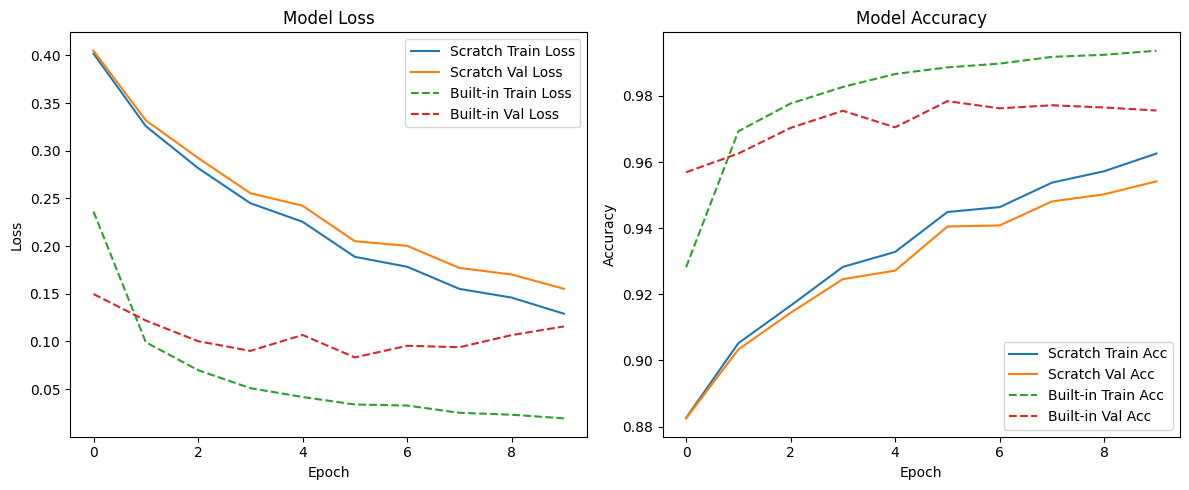


--- Interactive Testing ---


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
import numpy as np
import sys
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split



def extract_features(X):
    print("Starting Feature Extraction with VGG16...")
    
    if len(X.shape) == 3:
        X = X.reshape(-1, 28, 28, 1)
    
    X = tf.image.resize(X, [32, 32])
    
    X = tf.image.grayscale_to_rgb(X)
    
    X = preprocess_input(X)

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    
    features = base_model.predict(X, batch_size=64, verbose=1)
    
    features_flat = features.reshape(features.shape[0], -1)
    
    print(f"Feature extraction complete. Shape: {features_flat.shape}")
    
    return features_flat

def plot_results(history_scratch, history_builtin=None):
    """
    Plot training/validation loss and accuracy.
    Requirement: Plot loss and accuracy in single figures.
    """
   
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_scratch['loss'], label='Scratch Train Loss')
    if history_scratch.get('val_loss'):
        plt.plot(history_scratch['val_loss'], label='Scratch Val Loss')
    
    if history_builtin:
        plt.plot(history_builtin.history['loss'], label='Built-in Train Loss', linestyle='--')
        if 'val_loss' in history_builtin.history:
            plt.plot(history_builtin.history['val_loss'], label='Built-in Val Loss', linestyle='--')
            
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

  
    plt.subplot(1, 2, 2)
    plt.plot(history_scratch['acc'], label='Scratch Train Acc')
    if history_scratch.get('val_acc'):
        plt.plot(history_scratch['val_acc'], label='Scratch Val Acc')

    if history_builtin:
        plt.plot(history_builtin.history['accuracy'], label='Built-in Train Acc', linestyle='--')
        if 'val_accuracy' in history_builtin.history:
            plt.plot(history_builtin.history['val_accuracy'], label='Built-in Val Acc', linestyle='--')

    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


ACTIVATIONS_GA = ['sigmoid','relu','tanh']
OPTIMIZERS_GA = ['SGD','Adam','RMSprop','Adagrad']
BATCH_SIZE_GA = [16,32,64,128]

def createIndividual():
    return {
        "layers": np.random.randint(1,6),
        "neurons": np.random.randint(32,513),
        "activation": np.random.choice(ACTIVATIONS_GA),
        "lr": 10 ** np.random.uniform(-5,-1),
        "batch_size": np.random.choice(BATCH_SIZE_GA),
        "optimizer": np.random.choice(OPTIMIZERS_GA),
        "epochs": np.random.randint(3,20),
        "highest_score": -1
    }

def ga_fitness(ind, X_train, Y_train, X_val, Y_val, input_dim):
    layer_sizes = [input_dim] + [ind['neurons']] * ind['layers'] + [10]
    hidden_acts = [ind['activation']] * ind['layers']
    net = NeuralNetwork(layer_sizes, hidden_acts, seed=42)

    history = net.train(
        X_train, Y_train,
        X_val, Y_val,
        ind['epochs'],
        ind['batch_size'],
        ind['lr'],
        0
    )
    return history['val_acc'][-1]

def selection(population, scores, num_select=3):
    idxs = np.random.choice(len(population), num_select, replace=False)
    best_idx = idxs[0]
    for i in idxs:
        if scores[i] > scores[best_idx]:
            best_idx = i
    return population[best_idx]

def crossover(parent1, parent2):
    child = {}
    for key in parent1:
        child[key] = parent1[key] if np.random.rand() < 0.5 else parent2[key]
    return child

def mutation(ind, rate=0.1):
    if np.random.rand() < rate:
        ind["layers"] = np.random.randint(1,6)
    if np.random.rand() < rate:
        ind["neurons"] = np.random.randint(32, 513)
    if np.random.rand() < rate:
        ind["activation"] = np.random.choice(ACTIVATIONS_GA)
    if np.random.rand() < rate:
        ind["lr"] = 10 ** np.random.uniform(-5, -1)
    if np.random.rand() < rate:
        ind["batch_size"] = np.random.choice(BATCH_SIZE_GA)
    if np.random.rand() < rate:
        ind["optimizer"] = np.random.choice(OPTIMIZERS_GA)
    if np.random.rand() < rate:
        ind["epochs"] = np.random.randint(3, 20)

    ind["highest_score"] = -1
    return ind

def genetic_algorithm(X_train, Y_train, X_val, Y_val, input_dim, pop_size=10, gens=5):
    population = [createIndividual() for _ in range(pop_size)]
    best_ind = None
    best_score = -1

    for gen in range(gens):
        print(f"\n/* Generation {gen + 1}   */")
        scores = []

        for i, ind in enumerate(population):
            score = ga_fitness(ind, X_train, Y_train, X_val, Y_val, input_dim)
            ind['highest_score'] = score
            scores.append(score)
            print(f"Individual {i + 1}: val_acc: {score}")

            if score > best_score:
                best_score = score
                best_ind = ind

        new_pop = []
        for _ in range(pop_size):
            p1 = selection(population, scores)
            p2 = selection(population, scores)
            child = mutation(crossover(p1.copy(), p2.copy()))
            new_pop.append(child)

        population = new_pop

    return best_ind, best_score

def random_configuration():
    return {
        "layers": np.random.randint(1, 6),
        "neurons": np.random.randint(32, 513),
        "activation": np.random.choice(ACTIVATIONS_GA),
        "lr": 10 ** np.random.uniform(-5, -1),
        "batch_size": np.random.choice(BATCH_SIZE_GA),
        "optimizer": np.random.choice(OPTIMIZERS_GA),
        "epochs": np.random.randint(3, 20)
    }

def rs_fitness(config, X_train, Y_train, X_val, Y_val, input_dim):
    layer_sizes = [input_dim] + [config['neurons']] * config['layers'] + [10]
    hidden_acts = [config['activation']] * config['layers']
    net = NeuralNetwork(layer_sizes, hidden_acts, seed=42)

    history = net.train(
        X_train, Y_train,
        X_val, Y_val,
        config['epochs'],
        config['batch_size'],
        config['lr'],
        0
    )
    return history['val_acc'][-1]

def random_search(X_train, Y_train, X_val, Y_val, input_dim, num_trials=20):
    best_config = None
    best_score = -1
    history = []

    for i in range(num_trials):
        print(f"\nTrial {i + 1}/{num_trials}")
        config = random_configuration()
        score = rs_fitness(config, X_train, Y_train, X_val, Y_val, input_dim)
        history.append((config, score))
        print(f"Validation Accuracy: {score}")

        if score > best_score:
            best_score = score
            best_config = config

    return best_config, best_score, history

def run_optimization(choice, X_train, Y_train, X_val, Y_val, input_dim):
    if choice == "1":
        print("\nRunning Genetic Algorithm Optimization...")
        best_config, best_score = genetic_algorithm(
            X_train, Y_train,
            X_val, Y_val,
            input_dim,
            pop_size=5,
            gens=2
        )
    elif choice == "2":
        print("\nRunning Random Search Optimization...")
        best_config, best_score, _ = random_search(
            X_train, Y_train,
            X_val, Y_val,
            input_dim,
            num_trials=10
        )
    else:
        print("Invalid choice. Exiting.")
        return None, None

    print("\nBest Hyperparameters Found:")
    for k, v in best_config.items():
        print(f"{k}: {v}")
    print("Best Validation Accuracy:", best_score)
    return best_config, best_score

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def tanh_func(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - tanh_func(z)**2

def softmax(z):
    z_shift = z - np.max(z, axis=0, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

class NeuralNetwork:
    def __init__(self, layer_sizes, hidden_activations, seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.hidden_activations = hidden_activations
        self.L = len(layer_sizes) - 1
        self.params = {}
        self._init_params()

    def _init_params(self):
        for l in range(1, self.L + 1):
            in_dim = self.layer_sizes[l - 1]
            out_dim = self.layer_sizes[l]
            act = None
            if l <= self.L - 1:
                act = self.hidden_activations[l - 1]
            else:
                act = "softmax"
            
            if act == "relu":
                self.params['W' + str(l)] = np.random.randn(out_dim, in_dim) * np.sqrt(2. / in_dim)
            elif act == "sigmoid":
                self.params['W' + str(l)] = np.random.randn(out_dim, in_dim) * np.sqrt(1. / in_dim)
            else:
                self.params['W' + str(l)] = np.random.randn(out_dim, in_dim) * 0.01
            self.params['b' + str(l)] = np.zeros((out_dim, 1))

    def forward(self, X):
        caches = {}
        A = X
        caches['A0'] = A
        for l in range(1, self.L + 1):
            W = self.params['W' + str(l)]
            b = self.params['b' + str(l)]
            Z = np.dot(W, A) + b
            if l == self.L:
                A = softmax(Z)
            else:
                act = self.hidden_activations[l - 1]
                if act == "relu":
                    A = relu(Z)
                elif act == "sigmoid":
                    A = sigmoid(Z)
                elif act == "tanh":
                    A = np.tanh(Z)    
                else:
                    raise ValueError("Unsupported activation: " + str(act))
            caches['Z' + str(l)] = Z
            caches['A' + str(l)] = A
        return A, caches

    def compute_loss(self, AL, Y):
        m = Y.shape[1]
        eps = 1e-12
        loss = -np.sum(Y * np.log(AL + eps)) / m
        return loss

    def backward(self, AL, Y, caches):
        grads = {}
        m = Y.shape[1]
        dZ = AL - Y
        for l in reversed(range(1, self.L + 1)):
            A_prev = caches['A' + str(l - 1)]
            W = self.params['W' + str(l)]
            dW = (1. / m) * np.dot(dZ, A_prev.T)
            db = (1. / m) * np.sum(dZ, axis=1, keepdims=True)
            grads['dW' + str(l)] = dW
            grads['db' + str(l)] = db
            if l > 1:
                W_curr = self.params['W' + str(l)]
                dA_prev = np.dot(W_curr.T, dZ)
                Z_prev = caches['Z' + str(l - 1)]
                act = self.hidden_activations[l - 2]
                if act == "relu":
                    dZ = dA_prev * relu_derivative(Z_prev)
                elif act == "sigmoid":
                    A_prev_layer = caches['A' + str(l - 1)]
                    dZ = dA_prev * sigmoid_derivative(A_prev_layer)
                elif act == "tanh":
                    A_prev_layer = caches['A' + str(l - 1)]
                    dZ = dA_prev * (1 - A_prev_layer ** 2)
                else:
                    raise ValueError("Unsupported activation in backward: " + str(act))
        return grads

    def update_params(self, grads, lr):
        for l in range(1, self.L + 1):
            self.params['W' + str(l)] -= lr * grads['dW' + str(l)]
            self.params['b' + str(l)] -= lr * grads['db' + str(l)]

    def train(self, X_train, Y_train, X_val=None, Y_val=None,
              epochs=20, batch_size=64, lr=0.1, print_every=1):
        m = X_train.shape[1]
        history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}
        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(m)
            X_shuf = X_train[:, perm]
            Y_shuf = Y_train[:, perm]

            for i in range(0, m, batch_size):
                X_batch = X_shuf[:, i:i + batch_size]
                Y_batch = Y_shuf[:, i:i + batch_size]
                AL, caches = self.forward(X_batch)
                grads = self.backward(AL, Y_batch, caches)
                self.update_params(grads, lr)

            AL_train, _ = self.forward(X_train)
            loss_train = self.compute_loss(AL_train, Y_train)
            preds_train = np.argmax(AL_train, axis=0)
            labels_train = np.argmax(Y_train, axis=0)
            acc_train = np.mean(preds_train == labels_train)

            history['loss'].append(loss_train)
            history['acc'].append(acc_train)

            if X_val is not None and Y_val is not None:
                AL_val, _ = self.forward(X_val)
                loss_val = self.compute_loss(AL_val, Y_val)
                preds_val = np.argmax(AL_val, axis=0)
                labels_val = np.argmax(Y_val, axis=0)
                acc_val = np.mean(preds_val == labels_val)
                history['val_loss'].append(loss_val)
                history['val_acc'].append(acc_val)
            else:
                loss_val = None
                acc_val = None

            if print_every > 0 and epoch % print_every == 0:
                if loss_val is not None:
                    print(f"Epoch {epoch}/{epochs} - loss: {loss_train:.4f} - acc: {acc_train:.4f} - val_loss: {loss_val:.4f} - val_acc: {acc_val:.4f}")
                else:
                    print(f"Epoch {epoch}/{epochs} - loss: {loss_train:.4f} - acc: {acc_train:.4f}")
        return history

    def predict_proba(self, X):
        AL, _ = self.forward(X)
        return AL
        
    def predict(self, X):
       
        AL = self.predict_proba(X)
        preds = np.argmax(AL, axis=0)
        return preds

    def predict_single(self, x):
        x_col = x.reshape(-1, 1)
        AL, _ = self.forward(x_col)
        pred = np.argmax(AL, axis=0)[0]
        print("Predicted class:", pred)
        return pred

def one_hot_encode(y, num_classes):
    m = y.shape[0]
    Y = np.zeros((num_classes, m))
    for i in range(m):
        Y[int(y[i]), i] = 1
    return Y


def main():
    print("========================================================")
    print("        CS Project: Neural Networks & Optimization      ")
    print("========================================================")

    
    print("\n[Step 1] Loading MNIST Data...")
    (x_raw_train, y_raw_train), (x_raw_test, y_raw_test) = tf.keras.datasets.mnist.load_data()
    
    print("[Step 2] Extracting Features (Flattening & Normalizing)...")
    X_full = extract_features(x_raw_train) 
    X_test_final = extract_features(x_raw_test) 
    y_full = y_raw_train
    y_test_final = y_raw_test

    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
    )

    X_train_scratch = X_train_split.T
    X_val_scratch = X_val_split.T
    X_test_scratch = X_test_final.T
    
    Y_train_scratch = one_hot_encode(y_train_split, 10)
    Y_val_scratch = one_hot_encode(y_val_split, 10)
    Y_test_scratch = one_hot_encode(y_test_final, 10)
    
    input_dim = X_train_scratch.shape[0]

    y_train_keras = to_categorical(y_train_split, 10)
    y_val_keras = to_categorical(y_val_split, 10)
    y_test_keras = to_categorical(y_test_final, 10)

    print(f"Data Loaded. Training samples: {X_train_split.shape[0]}, Validation: {X_val_split.shape[0]}, Test: {X_test_final.shape[0]}")

    print("\n--------------------------------------------------------")
    print(" SECTION A: From-Scratch Model & Optimization")
    print("--------------------------------------------------------")
    
    print("\nChoose Optimization Algorithm:")
    print("1 - Genetic Algorithm")
    print("2 - Random Search")
    choice = input("Enter choice (1 or 2): ").strip()

    best_config, best_score = run_optimization(choice, X_train_scratch, Y_train_scratch, X_val_scratch, Y_val_scratch, input_dim)

    if best_config is None:
        best_config = {
            "layers": 2, "neurons": 64, "activation": "relu", 
            "lr": 0.01, "batch_size": 64, "optimizer": "SGD", "epochs": 5
        }
        print("Using default config due to invalid choice.")

    print("\n[Step 3] Training From-Scratch Model with Best Hyperparameters...")
    layer_sizes = [input_dim] + [best_config['neurons']] * best_config['layers'] + [10]
    hidden_acts = [best_config['activation']] * best_config['layers']

    scratch_net = NeuralNetwork(layer_sizes, hidden_acts, seed=42)
    
    scratch_history = scratch_net.train(
        X_train_scratch, Y_train_scratch,
        X_val_scratch, Y_val_scratch,
        epochs=best_config['epochs'],
        batch_size=best_config['batch_size'],
        lr=best_config['lr'],
        print_every=1
    )

   
    scratch_preds_prob = scratch_net.predict_proba(X_test_scratch)
    scratch_preds = np.argmax(scratch_preds_prob, axis=0)
    scratch_acc = np.mean(scratch_preds == y_test_final)
    print(f"\nFrom-Scratch Model Test Accuracy: {scratch_acc:.4f}")

   
    print("\n--------------------------------------------------------")
    print(" SECTION B: Built-in Model (TensorFlow/Keras)")
    print("--------------------------------------------------------")
    
   
    print("Configure Built-in Model Architecture:")
    try:
        num_layers = int(input("Enter number of hidden layers: "))
        activation = input("Choose activation function (relu / sigmoid / tanh): ").lower()
        if activation not in ["relu", "sigmoid", "tanh"]:
            print("Invalid choice. Defaulting to ReLU.")
            activation = "relu"

        neurons = []
        for i in range(num_layers):
            n = int(input(f"Enter number of neurons in hidden layer {i+1}: "))
            neurons.append(n)
    except:
        print("Invalid input. Using default: 2 layers, 64 neurons, relu.")
        num_layers = 2
        neurons = [64, 64]
        activation = 'relu'

  
    model = Sequential()
    
    model.add(Dense(neurons[0], activation=activation, input_shape=(784,)))
   
    for n in neurons[1:]:
        model.add(Dense(n, activation=activation))
    
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001), 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n[Step 4] Training Built-in Keras Model...")
    keras_history = model.fit(
        X_train_split, y_train_keras,
        epochs=10, 
        batch_size=32,
        validation_data=(X_val_split, y_val_keras),
        verbose=1
    )

    loss, keras_acc = model.evaluate(X_test_final, y_test_keras, verbose=0)
    keras_preds_prob = model.predict(X_test_final, verbose=0)
    keras_preds = np.argmax(keras_preds_prob, axis=1)
    print(f"Built-in Model Test Accuracy: {keras_acc:.4f}")

    print("\n--------------------------------------------------------")
    print(" SECTION C: Comparison & Results ")
    print("--------------------------------------------------------")

    
    print("\n>>> Classification Report: FROM SCRATCH MODEL")
    print(classification_report(y_test_final, scratch_preds))

    print("\n>>> Classification Report: BUILT-IN MODEL")
    print(classification_report(y_test_final, keras_preds))

    print("\n>>> Confusion Matrix: FROM SCRATCH MODEL")
    print(confusion_matrix(y_test_final, scratch_preds))

    print("\n>>> Confusion Matrix: BUILT-IN MODEL")
    print(confusion_matrix(y_test_final, keras_preds))

    
    print("\n[Step 5] Plotting Results...")
    plot_results(scratch_history, keras_history)

    
    def predict_digit(index):
        
        scratch_p = scratch_net.predict_single(X_test_scratch[:, index])
        
        
        sample = X_test_final[index].reshape(1, 784)
        keras_p = np.argmax(model.predict(sample, verbose=0))
        
        actual_label = y_test_final[index]
        print(f"Index {index} | Actual: {actual_label} | Scratch Pred: {scratch_p} | Built-in Pred: {keras_p}")

    print("\n--- Interactive Testing ---")
    while True:
        cmd = input("\nEnter test image index (0-9999) to predict, or 'exit'/'q' to quit: ").strip().lower()
        if cmd in ['exit', 'q']:
            break
        if cmd.isdigit():
            idx = int(cmd)
            if 0 <= idx < X_test_final.shape[0]:
                predict_digit(idx)
            else:
                print("Index out of range.")
        else:
            print("Invalid command.")

if __name__ == "__main__":
    main()
